# Classiq Quantum Circuit Challenge

<!-- Updated on August 19, 2026 -->

Phase oracles are fundamental building blocks in quantum algorithms. They are used to mark solutions in Grover's algorithm, encode objective functions in algorithms such as QAOA, and construct quantum feature maps.

In this challenge, you will encode a rasterized Classiq logo as a quantum phase oracle—a circuit that applies conditional phase shifts based on a classical image. This tests your ability to efficiently compile classical logic into reversible quantum circuits, a core skill in quantum algorithm design.

<p align="center">
  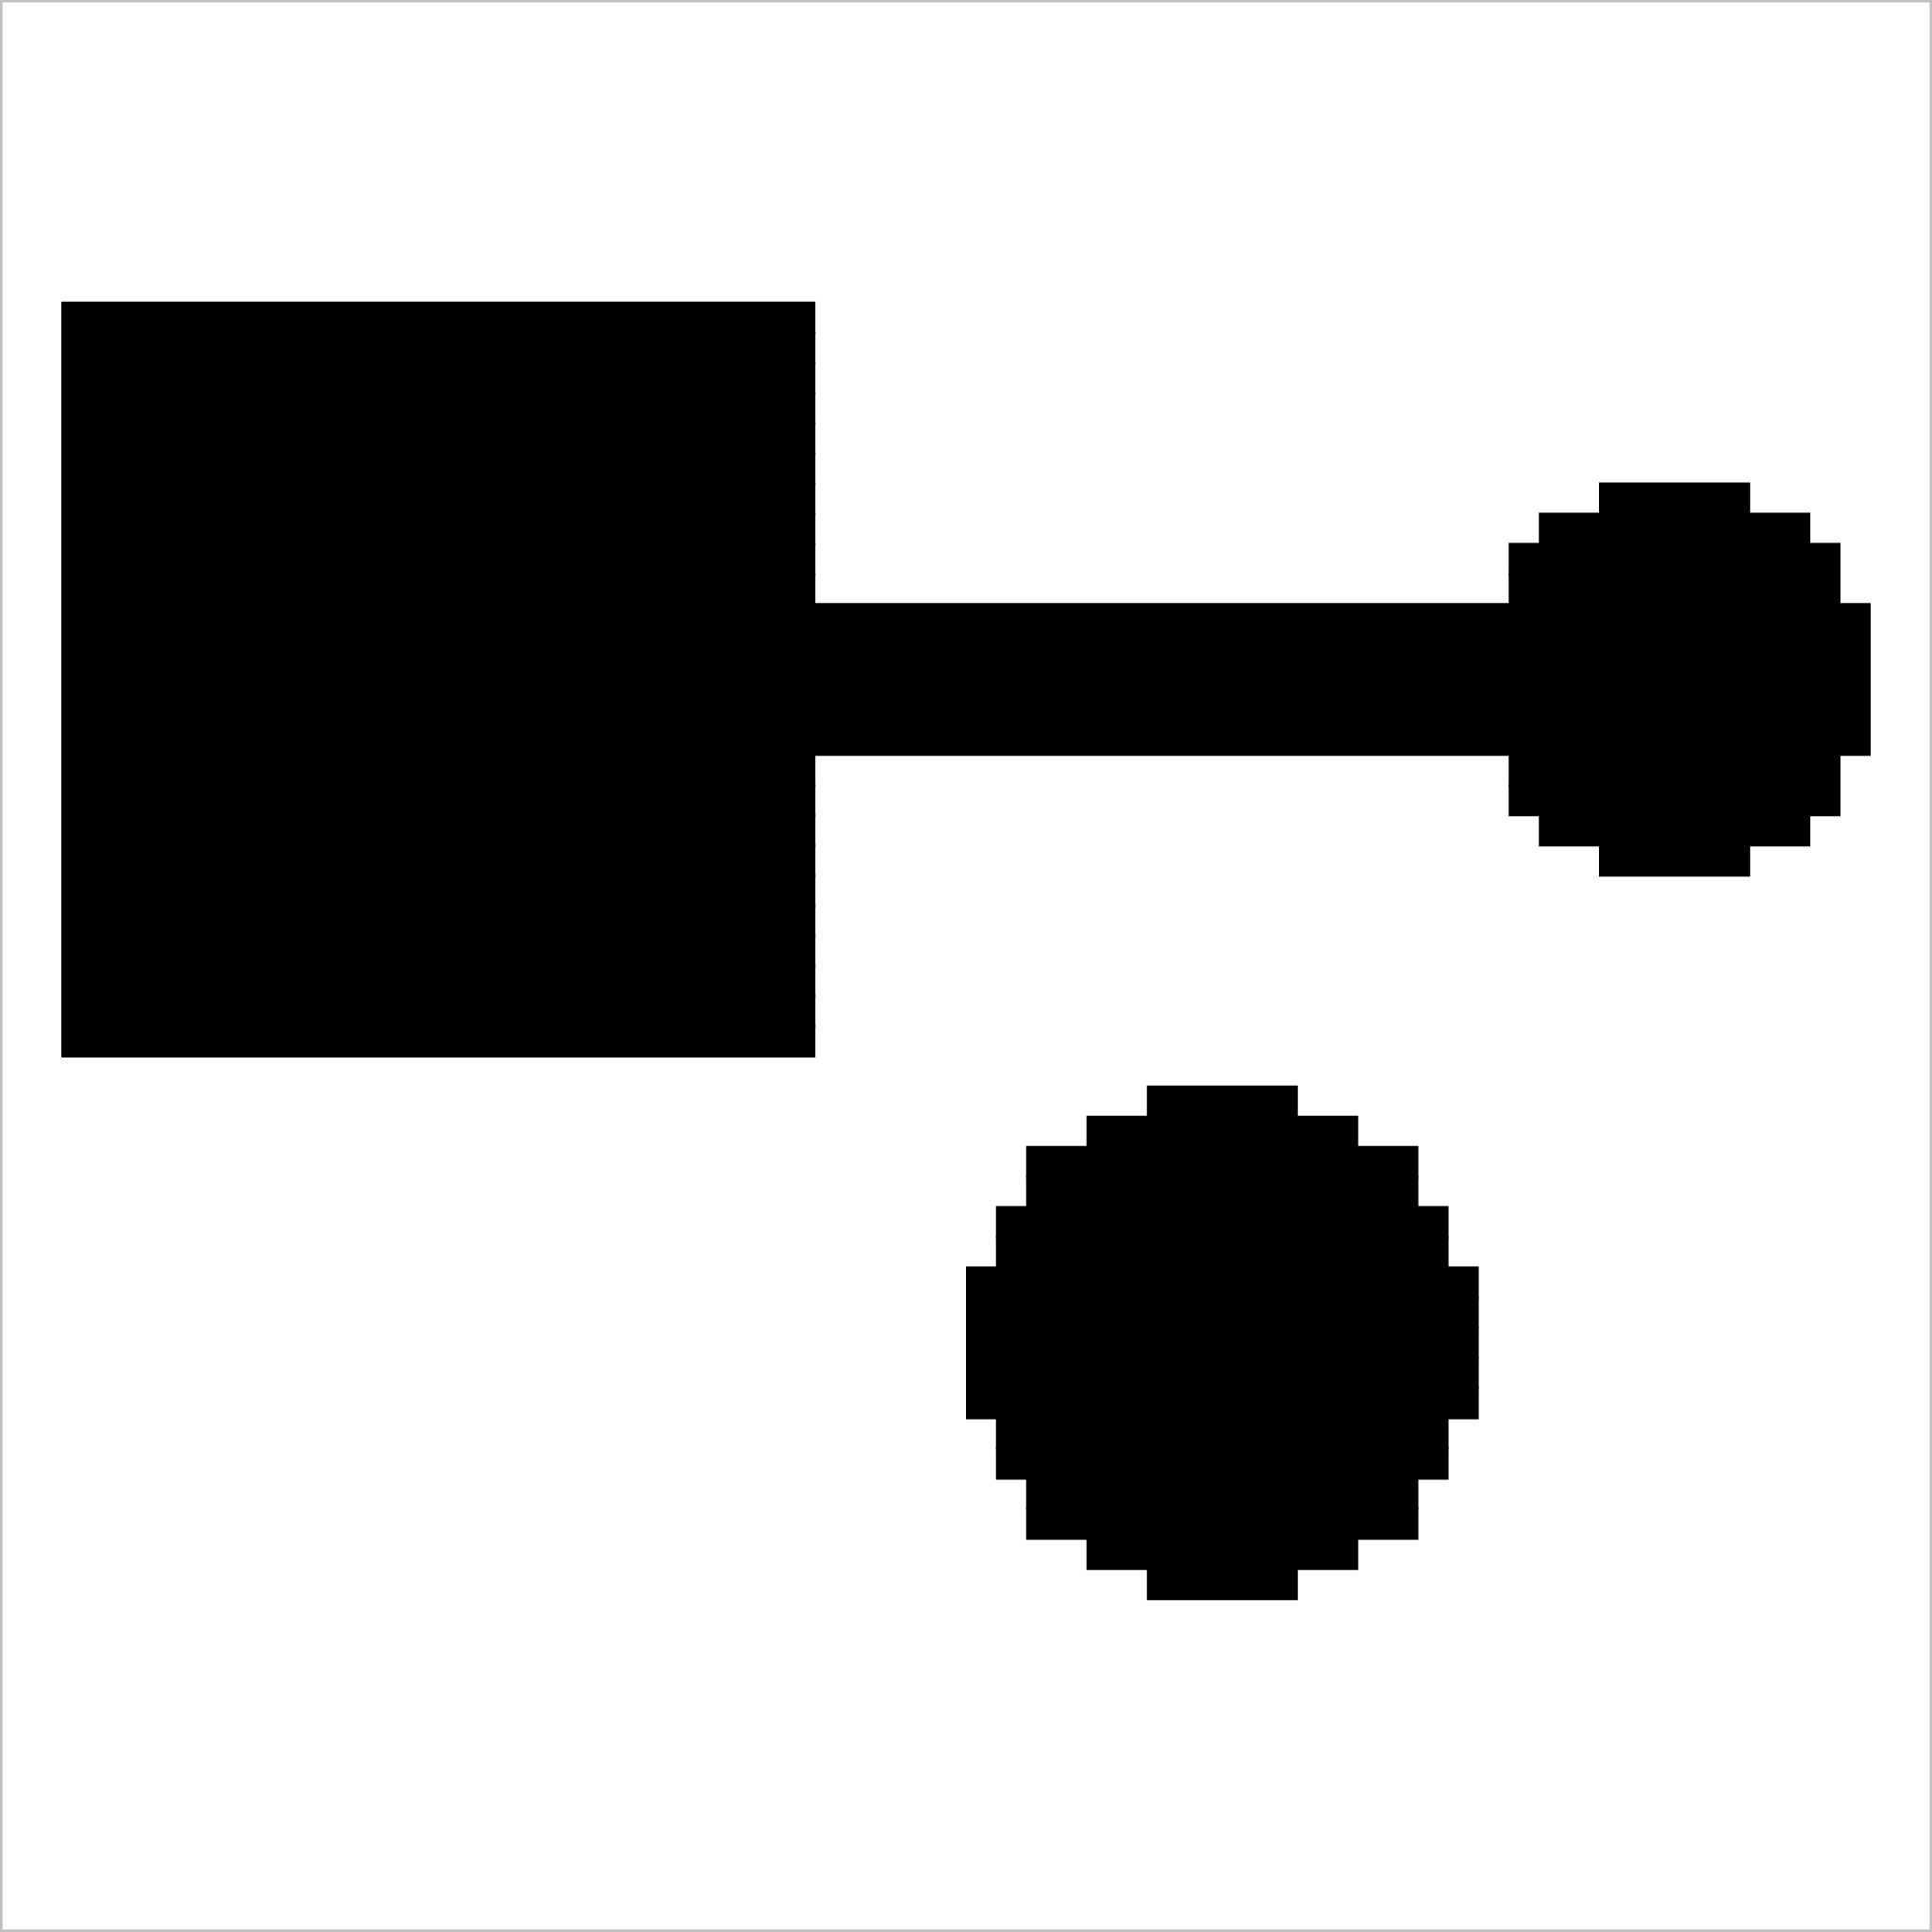
</p>

## Problem Specification

Given the 64×64 binary image shown above, construct a quantum circuit that implements the unitary transformation

$$
|x,y\rangle|0^a\rangle \longmapsto e^{i\phi}(-1)^{L(x,y)}|x,y\rangle|0^a\rangle,
$$

where:

- **$x, y$** are two 6-qubit coordinate registers ($0 \le x, y < 64$), encoded in qubits `q[0:6]` and `q[6:12]`, respectively;
- **$L(x,y)$** returns 1 if $(x,y)$ is a black pixel in the logo and 0 otherwise;
- **$\phi$** is a global phase independent of $x$ and $y$;
- **$|0^a\rangle$** is the initial and final state of up to 6 clean ancilla qubits, occupying wires in `q[12:18]`.

The target image contains exactly 1097 black and 2999 white pixels. Using Cartesian coordinates, with $x$ increasing to the right and $y$ increasing upward, the black region is the union of four geometric shapes (a square $S$, a horizontal bar $B$, and two filled disks $D_1$ and $D_2$):

$$
\begin{aligned}
S &= \{(x,y): 2 \le x \le 26,\ 29 \le y \le 53\},\\
B &= \{(x,y): 26 \le x \le 49,\ 39 \le y \le 43\},\\
D_1 &= \{(x,y): (x-55)^2+(y-41)^2 \le 42\},\\
D_2 &= \{(x,y): (x-40)^2+(y-19)^2 \le 72\}.
\end{aligned}
$$

### Constraints

- **Total circuit width:** exactly 12 qubits for coordinates plus up to 6 ancillas (at most 18 qubits in total).
- **Coordinate preservation:** the values of $x$ and $y$ must be unchanged.
- **Ancilla uncomputation:** all ancillas must be returned to $|0\rangle$ for every coordinate input.
- **Basis gates:** after transpilation, the circuit must use only `u3` and `cx` gates with all-to-all qubit connectivity.
- **Global phase:** the same global phase $\phi$ applies to all coordinate inputs.

### Submission and Grading

Submit both the Qmod source `*.qmod`, which records the solution approach, and a transpiled OpenQASM 2.0 circuit `*.qasm`. The QASM file is the authoritative standalone oracle for correctness verification and scoring. Submissions are limited to one per user per hour. Only each user's highest-scoring submission will be retained.

The grader will:

1. **Verify correctness:** reject any circuit that does not satisfy the specification (changed coordinates, nonzero ancillas, or coordinate-dependent phase).
2. **Enforce constraints:** verify that the circuit uses at most 18 qubits and that all ancillas are clean and returned to $|0\rangle$.
3. **Rank:** order valid submissions by transpiled circuit depth (the lower the better). For two submissions with the same circuit depth, the CX gate count will be used as the tiebreaker (the lower the better). If needed, the submission time will be used as a second tiebreaker, with the earlier solution ranked higher.

### Optimization Directions

This notebook provides an exact but deliberately inefficient baseline implementation, leaving ample room for improvement. You can reduce the circuit depth further by:

- Repartitioning regions whose row widths change so that predicates can be shared more effectively.
- Classifying rows first and then checking one or two $x$ intervals.
- Using Boolean decompositions (decision trees, BDD, ESOP) instead of direct predicate evaluation.
- Sharing repeated comparisons across multiple rectangle checks.
- Exploiting geometric symmetry in the logo structure.
- Trading recomputation for workspace within the six-ancilla budget.

## Setup

If you are running this notebook in [Classiq Studio](https://platform.classiq.io/studio/), the Classiq SDK is already installed and authenticated. Simply run the code cells below.

If you are running locally, uncomment the `%pip install` line in the next cell to install the SDK. You will also need to uncomment `classiq.authenticate()` and follow the authentication flow once to set up your credentials. For details, see [Classiq documentation](https://docs.classiq.io/getting-started/sdk_installation).

In [1]:
# Local installation, if needed:
# %pip install -q classiq numpy matplotlib

import re
import warnings
from pathlib import Path

import classiq
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
from classiq import *
from classiq.qmod.symbolic import pi
from classiq.interface.generator.hardware.hardware_data import CustomHardwareSettings

# classiq.authenticate()  # Uncomment once on a new machine.
print(f"Classiq SDK version: {classiq.__version__}")

Classiq SDK version: 1.26.0


## Baseline Implementation

The baseline solution implements the oracle using a **rectangle decomposition**: we partition the 64×64 image into a set of axis-aligned rectangles that exactly cover all black pixels. For each rectangle, we apply a phase shift when the coordinate pair $(x,y)$ falls within its bounds.

### Step 1: Compute the Rectangle Cover

We compute a disjoint rectangle cover by finding contiguous black intervals on each row, then merging identical intervals across adjacent rows into larger rectangles. This decomposition is exact but deliberately not optimized: it leaves substantial room for improvement through repartitioning, predicate sharing, or other techniques.

In [2]:
GRID_SIZE = 64
COORD_BITS = 6


def logo_pixel(x: int, y: int) -> bool:
    """Return True exactly for black pixel (x, y)."""
    return (
        (2 <= x <= 26 and 29 <= y <= 53)
        or (26 <= x <= 49 and 39 <= y <= 43)
        or (x - 55) ** 2 + (y - 41) ** 2 <= 42
        or (x - 40) ** 2 + (y - 19) ** 2 <= 72
    )


def intervals_for_row(y: int) -> tuple[tuple[int, int], ...]:
    """Return the contiguous black-pixel intervals in row y."""
    xs = [x for x in range(GRID_SIZE) if logo_pixel(x, y)]
    if not xs:
        return ()

    intervals: list[tuple[int, int]] = []
    start = xs[0]
    end = xs[0]
    for x in xs[1:]:
        if x == end + 1:
            end = x
        else:
            intervals.append((start, end))
            start = x
            end = x
    intervals.append((start, end))
    return tuple(intervals)


def merge_equal_intervals() -> tuple[tuple[int, int, int, int], ...]:
    """Merge equal intervals on adjacent rows into disjoint rectangles."""
    active: dict[tuple[int, int], int] = {}
    rectangles: list[tuple[int, int, int, int]] = []

    for y in range(GRID_SIZE + 1):
        intervals = set(intervals_for_row(y)) if y < GRID_SIZE else set()

        for interval, y_min in tuple(active.items()):
            if interval not in intervals:
                rectangles.append((*interval, y_min, y - 1))
                del active[interval]

        for interval in intervals:
            active.setdefault(interval, y)

    return tuple(sorted(rectangles, key=lambda block: (block[2], block[0])))


ORACLE_RECTANGLES = merge_equal_intervals()

target_mask = np.array(
    [[logo_pixel(x, y) for x in range(GRID_SIZE)] for y in range(GRID_SIZE)]
)
if target_mask.sum() != 1097:
    raise RuntimeError("Target mask must contain exactly 1097 black pixels")

cover_mask = np.zeros_like(target_mask)
for x_min, x_max, y_min, y_max in ORACLE_RECTANGLES:
    block = np.s_[y_min : y_max + 1, x_min : x_max + 1]
    if cover_mask[block].any():
        raise RuntimeError(
            f"Rectangle cover is not disjoint: {(x_min, x_max, y_min, y_max)}"
        )
    cover_mask[block] = True

if not np.array_equal(cover_mask, target_mask):
    raise RuntimeError("Rectangle cover does not match the target mask")

print(
    f"{target_mask.sum()} black pixels covered by "
    f"{len(ORACLE_RECTANGLES)} disjoint rectangles"
)

1097 black pixels covered by 18 disjoint rectangles


The code above produces 18 disjoint rectangles covering all 1097 black pixels, with heights ranging from 1 to 10. The visualization below shows the target image and its rectangle cover (orange outlines). Notice that many adjacent rectangles are narrow (width or height ≤ 2), which reveals obvious opportunities for optimization through consolidation and predicate sharing.

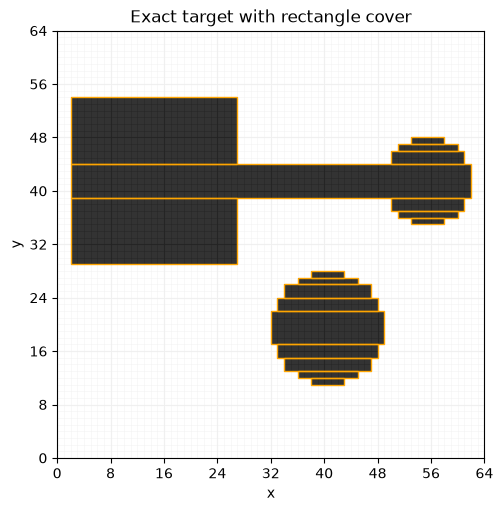

In [3]:
fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)
ax.imshow(
    target_mask,
    origin="lower",
    cmap="gray_r",
    interpolation="nearest",
    extent=(0, GRID_SIZE, 0, GRID_SIZE),
    alpha=0.8,
    zorder=2,
)
ax.set_title("Exact target with rectangle cover")
ax.set_xlabel("x")
ax.set_ylabel("y")

for x_min, x_max, y_min, y_max in ORACLE_RECTANGLES:
    ax.add_patch(
        patches.Rectangle(
            (x_min, y_min),
            x_max - x_min + 1,
            y_max - y_min + 1,
            fill=False,
            edgecolor="orange",
            zorder=3,
        )
    )

axis_ticks = range(0, GRID_SIZE + 1, 8)
ax.set_xticks(axis_ticks)
ax.set_yticks(axis_ticks)
pixel_boundaries = range(GRID_SIZE + 1)
ax.set_xticks(pixel_boundaries, minor=True)
ax.set_yticks(pixel_boundaries, minor=True)
ax.set_xlim(0, GRID_SIZE)
ax.set_ylim(0, GRID_SIZE)
ax.grid(which="minor", linewidth=0.5, alpha=0.6, zorder=1)
ax.grid(which="major", linewidth=0.8, alpha=0.9, zorder=1)
ax.tick_params(which="minor", length=0)

plt.show()

### Step 2: Define the Phase Oracle

The oracle applies a phase shift of $\pi$ (a factor of $-1$) to the quantum state if and only if the coordinate pair $(x,y)$ lies within one of the computed rectangles. Since the rectangle cover is disjoint, each black pixel is covered by exactly one rectangle, so each black coordinate pair receives exactly one phase factor of $-1$. White pixels receive no phase shift.

**Predicates.** A predicate is a Boolean condition that evaluates to true or false for each input. In the code below, expressions like `(x >= x_min) & (x <= x_max)` are predicates—they return true when the condition holds and false otherwise. The `control` statement applies the phase shift only when a predicate evaluates to true. Optimizing submissions often involves sharing common predicates across multiple conditions or restructuring them to reduce circuit depth.

The `@qperm` decorator declares a computational-basis permutation that may include phase shifts. Declaring both coordinate registers as `Const` makes them immutable up to phase. Because the function body applies only conditional phases, the resulting operation is diagonal in the computational basis and preserves both coordinates.

In [4]:
@qperm
def logo_phase_oracle(x: Const[QNum], y: Const[QNum]) -> None:
    """Apply the exact logo phase oracle to the coordinate registers."""
    for x_min, x_max, y_min, y_max in ORACLE_RECTANGLES:
        y_condition = (
            y == y_min
            if y_min == y_max
            else (y >= y_min) & (y <= y_max)
        )
        rectangle_condition = (
            (x >= x_min) & (x <= x_max) & y_condition
        )
        control(rectangle_condition, lambda: phase(pi))

### Step 3: Synthesis Harness with Hadamard Preparation

In this model, the coordinate registers are allocated inside the `main` entry point and therefore begin in $|0\rangle^{\otimes 12}$. If the oracle were called immediately after allocation, the synthesis context would contain only that single basis state.

To give the optimizer a richer context, we prepare the superposition $|+\rangle^{\otimes 12}$ (via Hadamard gates on each coordinate qubit) before calling the oracle. All 4096 coordinate basis states then have nonzero amplitude in the synthesis context. The Hadamard preparation is **not part of the final circuit**—it is purely a synthesis harness. After synthesis, we remove the two top-level `hadamard_transform` calls from the QASM to produce a standalone oracle, which is then independently verified.

In [5]:
@qfunc
def main(
    x: Output[QNum[COORD_BITS]],
    y: Output[QNum[COORD_BITS]],
) -> None:
    """Prepare a full-support synthesis context and apply the logo oracle."""
    allocate(x)
    allocate(y)
    hadamard_transform(x)
    hadamard_transform(y)
    logo_phase_oracle(x, y)

### Step 4: Compile with Depth Optimization

We configure the Classiq synthesis engine to optimize for circuit depth with a maximum width of 18 qubits. The resulting Qmod source is saved for reproducibility, but the transpiled QASM circuit produced in the next step is the authoritative artifact for verification and scoring.

In [6]:
baseline_constraints = Constraints(
    optimization_parameter=OptimizationParameter.DEPTH,
    max_width=18,
)
model = create_model(main, constraints=baseline_constraints)
write_qmod(model, "submission")
print("Saved Qmod source to submission.qmod.")

qprog = synthesize(model)
show(qprog)

Saved Qmod source to submission.qmod.
Quantum program link: https://platform.classiq.io/circuit/3I9NLY5OSn1ANFplXHSOxgNH2Je


### Step 5: Extract the Standalone Oracle and Transpile

We first export the synthesized quantum program to OpenQASM 2.0 format. The resulting QASM contains the two top-level `hadamard_transform` calls we added for the synthesis harness. We locate and remove exactly those two calls, extracting a candidate standalone oracle that implements only the phase oracle itself.

We then transpile the candidate once into the fixed `u3`/`cx` basis with all-to-all qubit connectivity, so no routing overhead is introduced. We read circuit metrics off that transpiled program directly, then export it to the same QASM file used for submission. The final circuit uses little-endian encoding: $x$ on `q[0:6]`, $y$ on `q[6:12]`, and clean ancillas on the remaining wires. Step 6 remains the authoritative, format-validating check on the saved file.

In [7]:
raw_qasm = export(qprog, TargetLanguage.QASM2)
raw_lines = raw_qasm.splitlines()

# Locate the two top-level Hadamard preparation calls that belong to the
# synthesis harness. Removing them produces only a candidate standalone oracle.
preparation_indices = {
    index
    for index, line in enumerate(raw_lines)
    if line.lstrip().startswith("hadamard_transform_") and "q[" in line
}
if len(preparation_indices) != 2:
    raise RuntimeError(
        "Could not safely extract the candidate oracle: expected exactly "
        f"two Hadamard preparation calls, found {len(preparation_indices)}"
    )

candidate_qasm = "\n".join(
    line
    for index, line in enumerate(raw_lines)
    if index not in preparation_indices
)
candidate_qprog = quantum_program_from_qasm(candidate_qasm)

# Transpile once to the fixed basis used for submission and scoring.
transpiled = classiq.transpile(
    candidate_qprog,
    preferences=Preferences(
        transpilation_option=TranspilationOption.AUTO_OPTIMIZE,
        custom_hardware_settings=CustomHardwareSettings(basis_gates=["u3", "cx"]),
    ),
)
metrics = classiq.get_transpiled_circuit_metrics(transpiled)
print(f"width    = {metrics.width}")
print(f"depth    = {metrics.depth}")
print(f"CX count = {metrics.count_ops.get('cx', 0)}")

submission_qasm = export(
    transpiled,
    TargetLanguage.QASM2,
    transpilation_config=TranspilationConfig(basis_gates=["u3", "cx"]),
)
QASM_PATH = Path("submission.qasm")
QASM_PATH.write_text(submission_qasm, encoding="utf-8")

print("Saved QASM oracle to submission.qasm.")
print("Run Step 6 before treating this QASM as a valid submission.")

width    = 18
depth    = 5329
CX count = 3502
Saved QASM oracle to submission.qasm.
Run Step 6 before treating this QASM as a valid submission.


### Step 6: Verify the QASM Submission

The verifier reads `submission.qasm` directly and never simulates the earlier Qmod model. It first enforces the width and fixed `u3`/`cx` basis and computes the circuit depth and CX count.

For correctness, it tests three equal-magnitude product-phase inputs generated at runtime. Each state has nonzero amplitude on all 4096 coordinates, with every ancilla initialized to $|0\rangle$. The resulting Classiq statevectors are checked for coordinate preservation, clean ancillas, normalization, and the target phase pattern using one shared global phase.

The test circuits exist only in memory, so `submission.qasm` remains unchanged and authoritative for scoring. This is a strong finite-precision probabilistic check; an official grader can use additional private random states.

In [8]:
# Numerical precision thresholds for statevector verification.
STATE_ERROR_THRESHOLD = 1e-10
NORMALIZATION_ERROR_THRESHOLD = 1e-10


def qasm_metrics(source: str) -> tuple[int, int, int]:
    """Return width, depth, and CX count for a u3/cx QASM 2.0 file."""
    statements = [
        statement.strip()
        for statement in re.sub(r"//[^\n]*", "", source).split(";")
        if statement.strip()
    ]
    if statements[:2] != ["OPENQASM 2.0", 'include "qelib1.inc"']:
        raise ValueError("Expected an OpenQASM 2.0 file using qelib1.inc")

    qreg_match = (
        re.fullmatch(r"qreg\s+q\s*\[\s*(\d+)\s*\]", statements[2])
        if len(statements) >= 3
        else None
    )
    if qreg_match is None:
        raise ValueError("Expected exactly one register named q")

    width = int(qreg_match.group(1))
    if not 12 <= width <= 18:
        raise ValueError(f"QASM width must be between 12 and 18, got {width}")
    qubit_depths = [0] * width
    cx_count = 0

    for statement in statements[3:]:
        u3_match = re.fullmatch(
            r"u3\s*\([^,]+,[^,]+,[^,]+\)\s+q\s*\[\s*(\d+)\s*\]",
            statement,
        )
        cx_match = re.fullmatch(
            r"cx\s+q\s*\[\s*(\d+)\s*\]\s*,"
            r"\s*q\s*\[\s*(\d+)\s*\]",
            statement,
        )
        if u3_match:
            qubits = (int(u3_match.group(1)),)
        elif cx_match:
            qubits = tuple(map(int, cx_match.groups()))
            cx_count += 1
        else:
            raise ValueError(f"Unsupported QASM statement: {statement}")

        if any(qubit >= width for qubit in qubits):
            raise ValueError(
                f"Qubit index outside q[0]...q[{width - 1}]: {statement}"
            )
        if len(set(qubits)) != len(qubits):
            raise ValueError(f"Gate operands must be distinct: {statement}")

        layer = max(qubit_depths[qubit] for qubit in qubits) + 1
        for qubit in qubits:
            qubit_depths[qubit] = layer

    return width, max(qubit_depths, default=0), cx_count


def dense_classiq_statevector(frame, width: int) -> tuple[np.ndarray, float]:
    """Validate Classiq output and reconstruct the full physical vector."""
    statevector = np.zeros(1 << width, dtype=np.complex128)
    seen_basis_states: set[int] = set()

    for row in frame.itertuples(index=False):
        bitstring = str(row.bitstring).replace(" ", "")
        if len(bitstring) != width or set(bitstring) - {"0", "1"}:
            raise ValueError(f"Unexpected Classiq bitstring: {row.bitstring}")
        basis_index = int(bitstring, 2)
        if basis_index in seen_basis_states:
            raise ValueError(f"Duplicate Classiq basis state: {bitstring}")

        amplitude = complex(row.amplitude)
        if not np.isfinite(amplitude.real) or not np.isfinite(amplitude.imag):
            raise ValueError(f"Non-finite Classiq amplitude at {bitstring}")
        seen_basis_states.add(basis_index)
        statevector[basis_index] = amplitude

    if not seen_basis_states:
        raise ValueError("Classiq simulator returned an empty statevector")

    normalization_error = abs(np.vdot(statevector, statevector).real - 1)
    if normalization_error >= NORMALIZATION_ERROR_THRESHOLD:
        raise ValueError(
            f"Classiq statevector is not normalized: {normalization_error:.3e}"
        )
    return statevector, normalization_error

submission_source = QASM_PATH.read_text(encoding="utf-8")
submission_width, depth, cx_count = qasm_metrics(submission_source)

logical_size = GRID_SIZE**2
rng = np.random.default_rng()
random_phases = rng.uniform(
    -np.pi, np.pi, size=(3, 2 * COORD_BITS)
)
target_phases = np.array(
    [
        -1 if logo_pixel(x, y) else 1
        for y in range(GRID_SIZE)
        for x in range(GRID_SIZE)
    ],
    dtype=np.complex128,
)

source_without_comments = re.sub(
    r"//[^\n]*",
    lambda match: " " * len(match.group()),
    submission_source,
)
qreg_matches = list(
    re.finditer(
        rf"\bqreg\s+q\s*\[\s*{submission_width}\s*\]\s*;",
        source_without_comments,
    )
)
if len(qreg_matches) != 1:
    raise ValueError("QASM must contain exactly one matching q register")
insertion_index = qreg_matches[0].end()
basis = np.arange(logical_size, dtype=np.uint16)
max_error = ancilla_error = normalization_error = 0.0
shared_global_phase = 1 + 0j

# Raw QASM has no named Classiq outputs, so Classiq labels its wires as
# auxiliary. We validate the actual ancilla wires explicitly below.
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="Non-zero amplitudes were detected in states with non-zero auxiliary values.*",
    )
    for test_index, phases in enumerate(random_phases):
        preparation = [
            f"u3(pi/2,{phase:.17g},0) q[{qubit}];"
            for qubit, phase in enumerate(phases)
        ]
        test_qasm = (
            submission_source[:insertion_index]
            + "\n"
            + "\n".join(preparation)
            + submission_source[insertion_index:]
        )

        with ExecutionSession(
            test_qasm,
            backend="classiq/simulator",
            transpilation_option=TranspilationOption.DECOMPOSE,
        ) as session:
            classiq_frame = session.calculate_state_vector(
                amplitude_threshold=0.0
            )

        statevector, state_normalization_error = dense_classiq_statevector(
            classiq_frame, submission_width
        )
        normalization_error = max(
            normalization_error, state_normalization_error
        )

        # Ancillas are the higher-index wires, so indices below 4096 have
        # q[12:] = |0...0> under the required little-endian convention.
        ancilla_error = max(
            ancilla_error,
            np.max(np.abs(statevector[logical_size:]), initial=0.0),
        )

        basis_phases = np.zeros(logical_size)
        for qubit, phase in enumerate(phases):
            basis_phases += ((basis >> qubit) & 1) * phase

        expected_state = np.zeros(1 << submission_width, dtype=np.complex128)
        expected_state[:logical_size] = (
            np.exp(1j * basis_phases) / np.sqrt(logical_size) * target_phases
        )
        if test_index == 0:
            overlap = np.vdot(expected_state, statevector)
            if abs(overlap) <= 1e-12:
                raise ValueError(
                    "Cannot determine a global phase from Classiq results"
                )
            shared_global_phase = overlap / abs(overlap)

        max_error = max(
            max_error,
            np.max(np.abs(statevector - shared_global_phase * expected_state)),
        )

if ancilla_error >= STATE_ERROR_THRESHOLD:
    raise ValueError(f"Classiq simulation left dirty ancillas: {ancilla_error:.3e}")
if max_error >= STATE_ERROR_THRESHOLD:
    raise ValueError(
        f"Classiq QASM verification failed: {max_error:.3e}"
    )

print(
    f"Successfully verified loaded QASM with score {depth}:\n"
    f"random states = {len(random_phases)}\n"
    f"width = {submission_width}\n"
    f"depth = {depth}\n"
    f"CX count = {cx_count}\n"
    f"max error = {max_error:.1e}\n"
    f"ancilla error = {ancilla_error:.1e}\n"
    f"normalization error = {normalization_error:.1e}"
)

Submitting state-vector job to simulator
Submitting state-vector job to simulator
Submitting state-vector job to simulator


Successfully verified loaded QASM with score 5329:
random states = 3
width = 18
depth = 5329
CX count = 3502
max error = 3.6e-16
ancilla error = 5.5e-17
normalization error = 2.8e-14


## References

- [Qmod quantum functions and `Const`](https://docs.classiq.io/qmod-reference/language-reference/functions) — Function signatures, parameter types, and the `Const` qualifier
- [Qmod `phase` statement](https://docs.classiq.io/qmod-reference/language-reference/statements/phase) — Applying global and relative phase shifts
- [Qmod uncomputation](https://docs.classiq.io/qmod-reference/language-reference/uncomputation) — Clean ancillas, automatic uncomputation, and `within_apply`
- [Classiq synthesis and optimization](https://docs.classiq.io/user-guide/synthesis) — Understanding synthesis parameters, constraints, and how synthesis responds to code structure
- [Quantum program transpilation](https://docs.classiq.io/user-guide/synthesis/quantum-program-transpilation) — Basis decomposition, optimization levels, and connectivity